In [12]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xgboost as xgb

In [13]:
# =============================================================================
# Benchmark Comparison
# =============================================================================

file_names = []

example = r'01_analysis_RealTest_Karlsruhe_200kPa' ## needs user interaction
path_user = r'C:\Users\haris\Documents\GitHub\MLpFEM\data\\'
path = path_user + example + "\\02_rawdata_interpolated\\"

file = r"Triaxial test_q_eps1.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:]  
q_opt = df_data_triax.iloc[1,:] 

file = r"Triaxial test_epsvol.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:] 
eps_vol_opt  = df_data_triax.iloc[1,:] 

file = r"Triaxial test_path.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
p_opt_path = df_data_triax.iloc[0,:] 
q_opt_path  = df_data_triax.iloc[1,:] 

file = r"Oedometer.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_oed_opt = df_data_triax.iloc[0,:]  
sig_1_opt  = df_data_triax.iloc[1,:] 


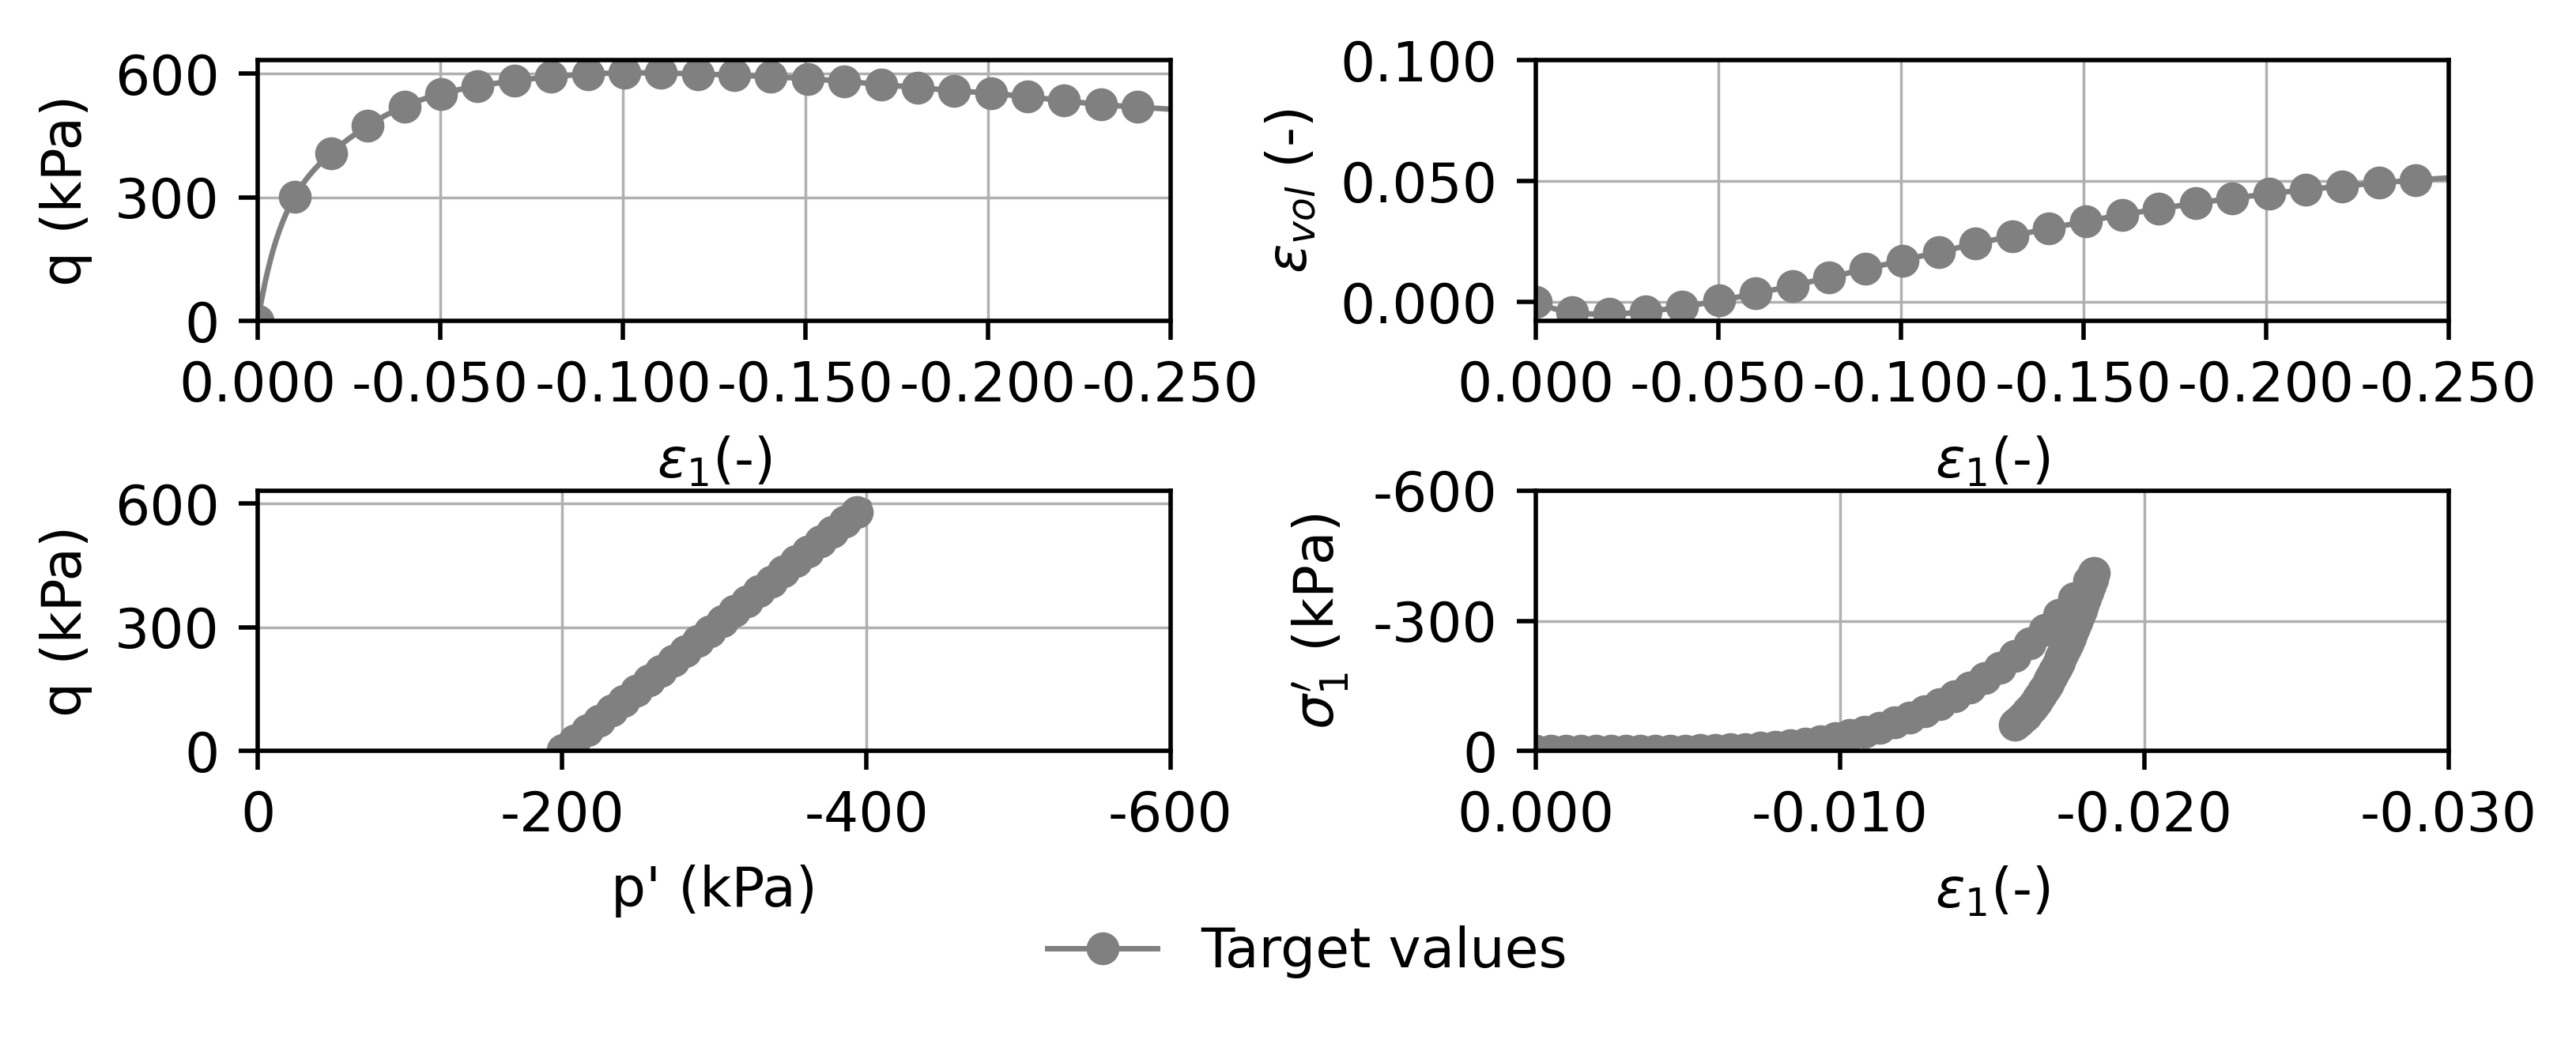

In [14]:
examples = [example]
folders = ['02_rawdata_interpolated\\']
labels = ['Target values']

colors = ['gray', 'b', 'r']
markers = ['o', 's', 'd', 's', '+']

markersizes = [5, 2, 2]
markeverys= [10,15,25]

cm = 1/2.54  # centimeters in inches

for k, example in enumerate(examples):
    fig, axs = plt.subplots(2, 2, figsize=(16*cm, 6*cm), dpi=500)

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]
    
            x = np.array(x)
            y = np.array(y)
    
            axs[j//2, j%2].plot(x, y, marker = markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            axs[j//2, j%2].grid(True, linewidth=0.5)
            axs[j//2, j%2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j//2, j%2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            
            axs[1, 0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    
            # Invert x-axis for all plots
            axs[j//2, j%2].invert_xaxis()

            # Invert y-axis for the last plot
            if j == len(file_names) - 1:
                axs[j//2, j%2].invert_yaxis()
    
            axs[j//2, j%2].set_xlabel('$\epsilon_{1}$(-)')
            axs[1, 0].set_xlabel("p' (kPa)")
            axs[0, 0].set_ylabel('q (kPa)')
            axs[1, 0].set_ylabel('q (kPa)')
            axs[0, 1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[1, 1].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 3: # oedoemeter
                default_ticks = axs[1, 0].get_xticks()
                axs[1, 0].set_yticks([0,300,600])
                axs[1, 0].set_ylim(0)
                axs[1, 0].set_xlim(xmin = 0, xmax = -600)
            if j == 0: # stress strain
                axs[0, 0].set_xlim(0, -0.25)
                axs[0, 0].set_yticks([0,300,600])
                axs[0, 0].set_ylim(0)
            if j == 1: # volumetric behaviour
                axs[0, 1].set_yticks([0, 0.05,0.10])
                axs[0, 1].set_xlim(0,-0.25)

            if j == 2: # stress path
                axs[1, 1].set_ylim(-600,0)
                axs[1, 1].set_yticks([0,-300,-600])
                axs[1, 1].set_xlim(-0.030,0)



                
    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(-.25, -.48), frameon=False, ncol=4)
    plt.subplots_adjust(left=0.08, right=0.96, bottom=0.24, top=0.98, wspace=0.40, hspace=0.65)

    plt.savefig(r"../graphics/"+"SyntheticData_"+f"{example}"+".png", dpi=1000)

In [15]:
#stack the data together
X_triax = np.hstack((q_opt, eps_y_opt, eps_vol_opt, eps_y_opt, q_opt_path, p_opt_path))
X_triax = np.reshape(X_triax, (1, -1))
X_triax = pd.DataFrame(X_triax)

X_oedo = np.hstack((sig_1_opt, eps_y_oed_opt))
X_oedo = np.reshape(X_oedo, (1, -1))
X_oedo = pd.DataFrame(X_oedo)

In [16]:
print("Triaxial test:", len(X_triax.columns))
print("Oedometer test:", len(X_oedo.columns))

Triaxial test: 1500
Oedometer test: 1500


In [17]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis =1)

In [18]:
X

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0.0,50.31892,94.314707,132.822529,166.580557,196.239401,222.370785,245.475527,265.990848,284.297069,...,-0.015735,-0.015728,-0.015721,-0.015714,-0.015706,-0.015699,-0.015692,-0.015685,-0.015677,-0.01567


In [19]:
# =============================================================================
# Benchmark Comparison
# =============================================================================
input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi','cref', 'psi', 
                'm', 'nu', 
                'Rf', 'K0NC', 'Cell pressure','pref']

loaded_model = xgb.Booster()
loaded_model.load_model(f"A_HS_model_200_kPa.bin")


d_eval_1 = xgb.DMatrix(X,)
predictions = loaded_model.predict(d_eval_1)

In [20]:
#model prediction
for i in range(len(input_column)):
    print(f"{input_column[i]}: {predictions[0,i]:.3f}")

E50ref: 20972.496
Eoedref: 21656.676
Eurref: 107278.656
phi: 37.423
cref: 0.000
psi: 7.594
m: 0.677
nu: 0.094
Rf: 0.952
K0NC: 0.408
Cell pressure: 200.000
pref: 100.000


In [21]:
with open(f'..\\data\pred_analysis_realTest_{example}.txt', 'w', encoding='utf-8') as file:
    for i in range(len(input_column)):
        file.write(f"{input_column[i]}: \t {predictions[0,i]:.3f}\n")

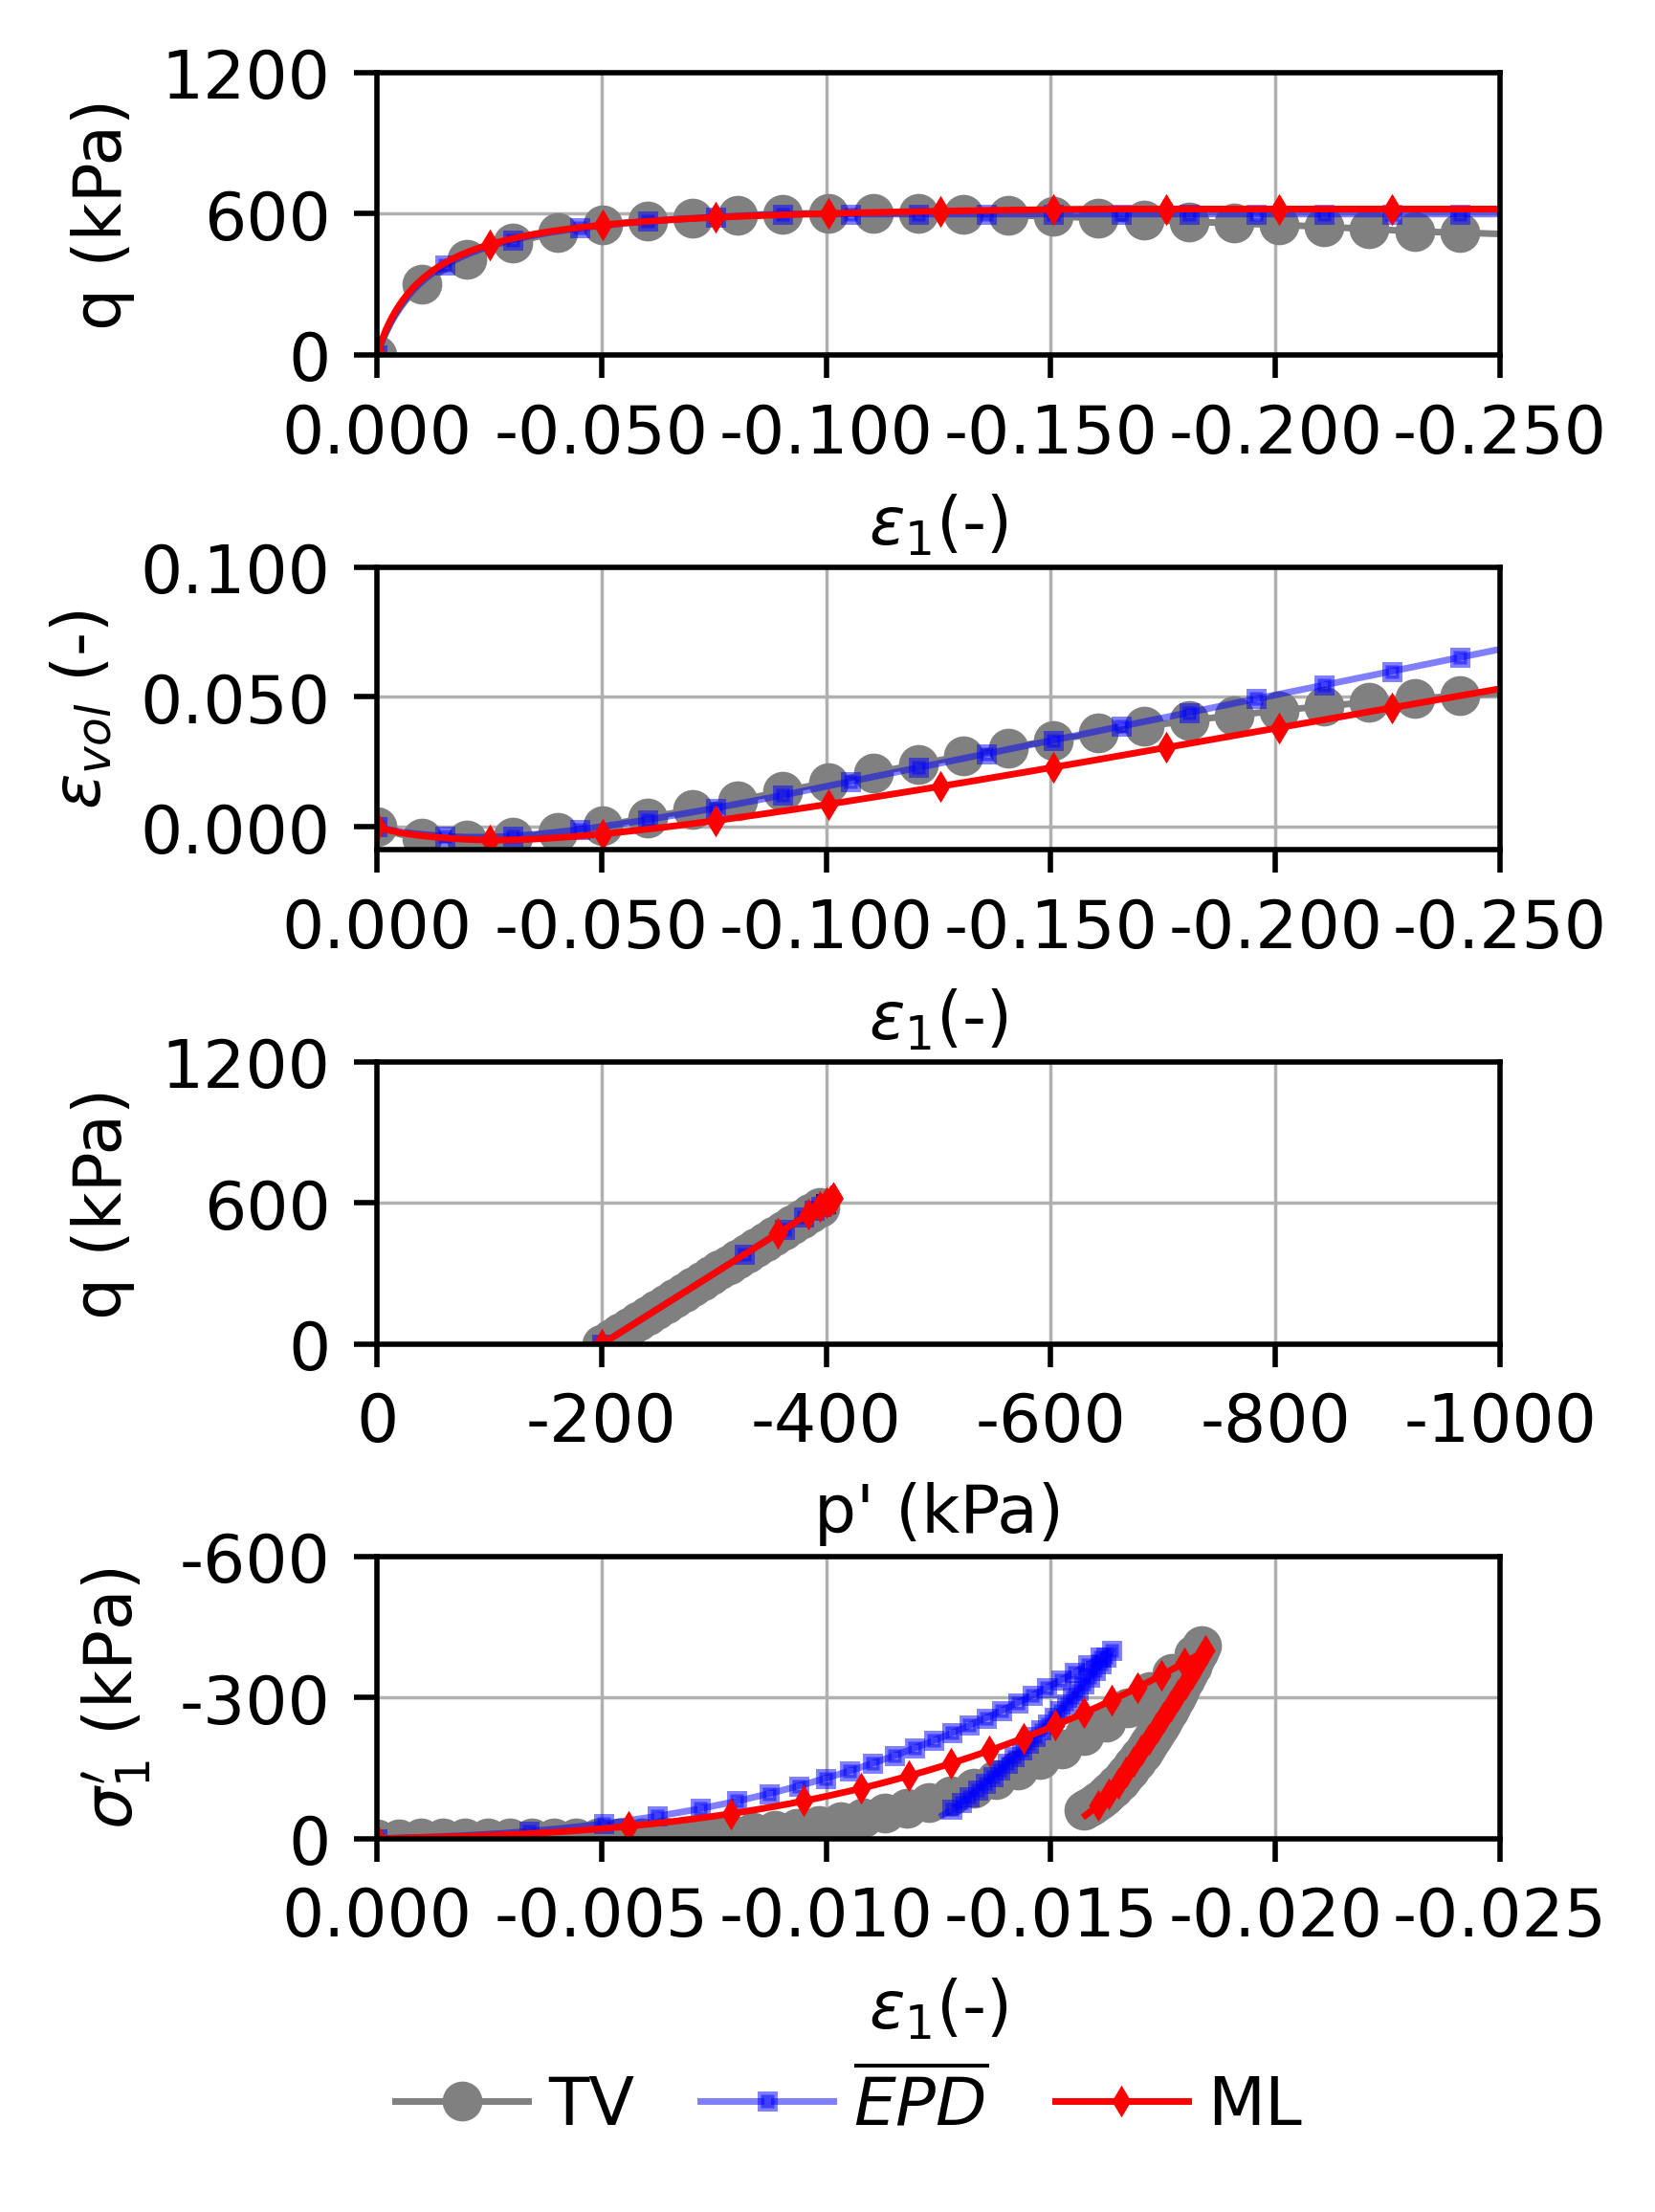

In [22]:
folders = ['02_rawdata_interpolated\\', '12_EPD\\', '10_MachineLearning\\']
labels = ['TV','$\\overline{EPD}$','ML',]
alphas = [1, 0.5, 1.0]

for k, example in enumerate(examples):
    fig, axs = plt.subplots(4, 1, figsize=(8.4 * cm, 11.1 * cm), dpi=500)  # Changed to 4 rows, 1 column

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]

            x = np.array(x)
            y = np.array(y)

            axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i], alpha=alphas[i]) 
            axs[j].grid(True, linewidth=0.5)
            axs[j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[3].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

            # Invert x-axis for all plots
            axs[j].invert_xaxis()

            axs[j].set_xlabel('$\epsilon_{1}$(-)')
            
            axs[2].set_xlabel("p' (kPa)")
            axs[0].set_ylabel('q (kPa)')
            axs[2].set_ylabel('q (kPa)')

            axs[1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[3].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 2:  # stress path
                default_ticks = axs[1].get_xticks()
                axs[2].set_yticks([0, 600, 1200])
                axs[2].set_ylim(0)
                axs[2].set_xlim(xmin=0, xmax=-1000)
            if j == 0:  # stress strain
                axs[0].set_xlim(0, -0.25)
                axs[0].set_yticks([0, 600, 1200])
                axs[0].set_ylim(0)
            if j == 1:  # volumetric behaviour
                axs[1].set_yticks([0, 0.05,0.10])
                axs[1].set_xlim(0, -0.25)

            if j == 3:  # oedoemeter
                axs[3].set_ylim(-600, 0)
                axs[3].set_yticks([0, -300, -600])
                axs[3].set_xlim(-0.025, 0)
                axs[3].invert_yaxis()
                axs[3].invert_xaxis()

    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(0.42, -.60), frameon=False, ncol=5, handletextpad=0.3, columnspacing=1)
    plt.subplots_adjust(left=0.22, right=0.93, bottom=0.14, top=0.985, wspace=0.40, hspace=0.75)
    plt.savefig(r"../graphics/" + "RealData" + f"{example}" + ".png", dpi=1000)